In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
df = pd.read_csv("Datasets.csv")
df.head()

,Id,CreatorUserId,OwnerUserId,OwnerOrganizationId,CurrentDatasetVersionId,CurrentDatasourceVersionId,ForumId,Type,CreationDate,LastActivityDate,TotalViews,TotalDownloads,TotalVotes,TotalKernels,Medal,MedalAwardDate
0,402034,2188609,2188609.0,NaN,771250.0,792478.0,414197,Dataset,10/31/2019 01:07:32,10/31/2019,2841,130,1,2,NaN,NaN
1,402031,3792299,3792299.0,NaN,771247.0,792475.0,414194,Dataset,10/31/2019 00:58:15,10/31/2019,1853,41,2,3,NaN,NaN
2,39875,1,1891177.0,NaN,285978.0,298457.0,48350,Dataset,08/01/2018 00:10:55,08/01/2018,8183,0,17,2,NaN,NaN
3,13,1132983,NaN,4.0,7651.0,7651.0,975,Dataset,12/18/2015 23:16:00,02/06/2018,260886,50472,422,452,1.0,07/22/2025
4,14,993,NaN,4.0,827864.0,850525.0,977,Dataset,12/21/2015 19:40:00,02/06/2018,558387,107547,946,499,1.0,07/22/2025


In [4]:
df = df[["CreationDate", "TotalViews", "TotalDownloads", "TotalVotes", "OwnerUserId"]]

df = df.sample(5000)
df.head()

,CreationDate,TotalViews,TotalDownloads,TotalVotes,OwnerUserId
686215,04/02/2026 10:54:50,12,0,0,33354557.0
214249,05/06/2023 15:35:49,241,13,0,10598458.0
394664,11/23/2024 18:35:52,203,4,0,20454252.0
29176,09/16/2018 22:58:01,1550,22,1,2254535.0
414473,01/09/2025 20:30:25,223,22,0,21079580.0


In [5]:
print(df.isnull().sum())

# drop missing
df.dropna(inplace=True)

CreationDate       0
TotalViews         0
TotalDownloads     0
TotalVotes         0
OwnerUserId       14
dtype: int64


In [6]:
df["TotalViews"] = df["TotalViews"].interpolate()
df["TotalDownloads"] = df["TotalDownloads"].interpolate()
df["TotalVotes"] = df["TotalVotes"].interpolate()

In [7]:
df["CreationDate"] = pd.to_datetime(df["CreationDate"])
df["Year"] = df["CreationDate"].dt.year

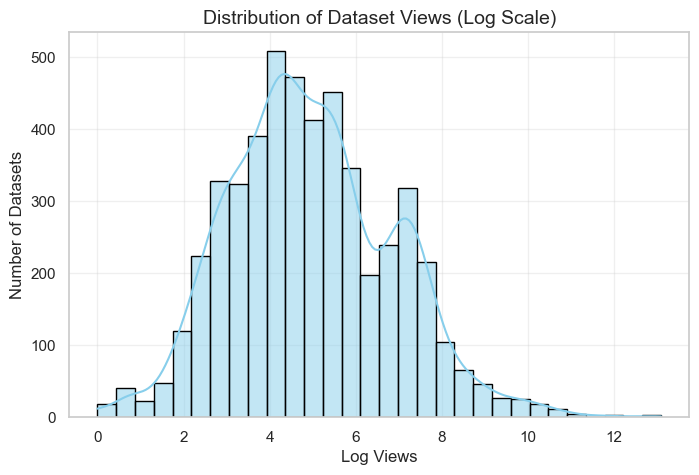

In [8]:
sns.histplot(np.log1p(df["TotalViews"]),
             bins=30,
             kde=True,
             color="skyblue",
             edgecolor="black")

plt.title("Distribution of Dataset Views (Log Scale)", fontsize=14)
plt.xlabel("Log Views")
plt.ylabel("Number of Datasets")

plt.grid(alpha=0.3)

plt.show()

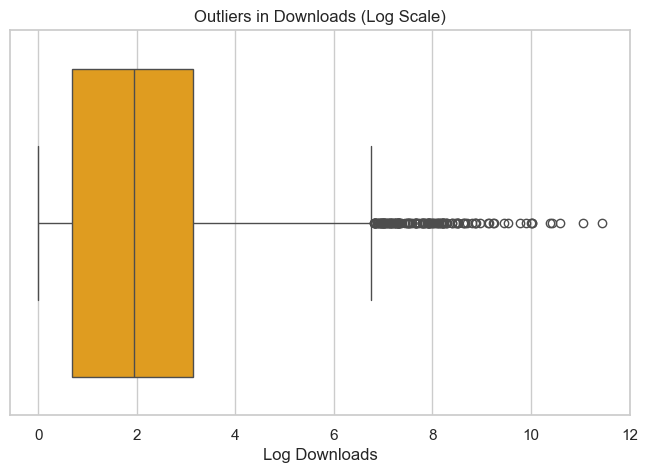

In [9]:
sns.boxplot(x=np.log1p(df["TotalDownloads"]), color="orange")

plt.title("Outliers in Downloads (Log Scale)")
plt.xlabel("Log Downloads")

plt.show()

In [10]:
year_data = df.groupby("Year")[["TotalViews","TotalDownloads","TotalVotes"]].mean()
year_data

,TotalViews,TotalDownloads,TotalVotes
Year,,,
2017,15617.000000,1805.700000,22.200000
2018,22428.366667,3622.566667,26.983333
2019,5952.414141,697.565657,10.444444
2020,4044.092000,376.844000,6.056000
2021,2637.594272,330.680191,4.143198
2022,853.691781,97.031963,2.933790
2023,1435.677673,224.820755,3.422956
2024,531.775432,91.867562,2.220729
2025,175.729481,30.042679,0.728825


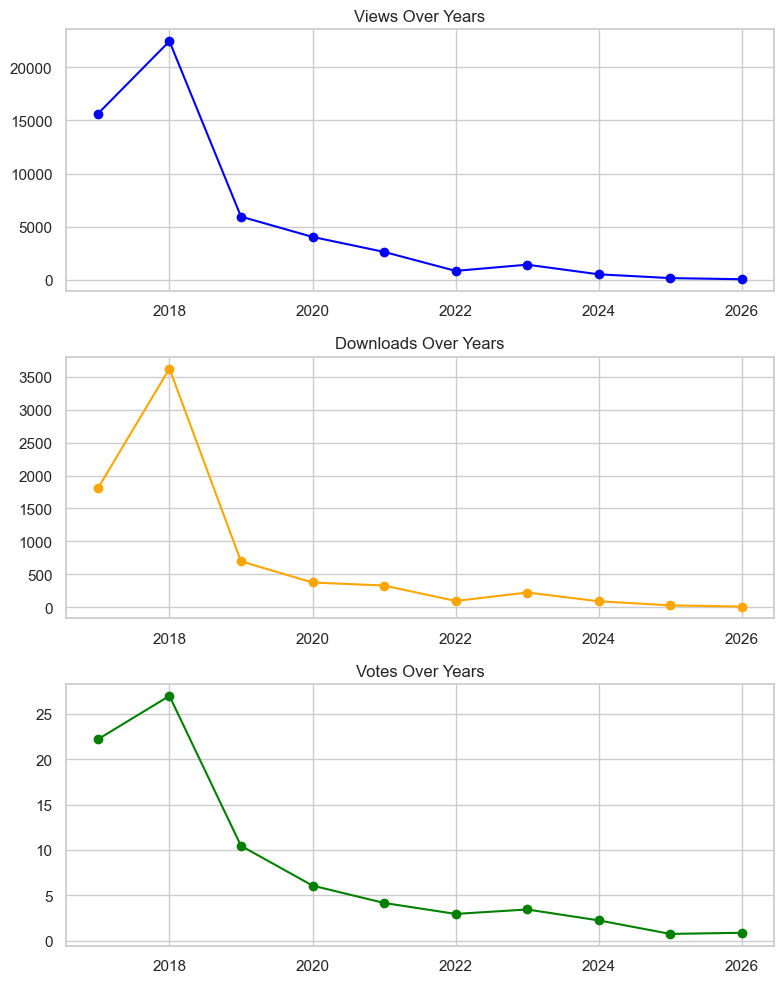

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(8,10))

ax[0].plot(year_data.index, year_data["TotalViews"], marker="o", color="blue")
ax[0].set_title("Views Over Years")

ax[1].plot(year_data.index, year_data["TotalDownloads"], marker="o", color="orange")
ax[1].set_title("Downloads Over Years")

ax[2].plot(year_data.index, year_data["TotalVotes"], marker="o", color="green")
ax[2].set_title("Votes Over Years")

plt.tight_layout()
plt.show()

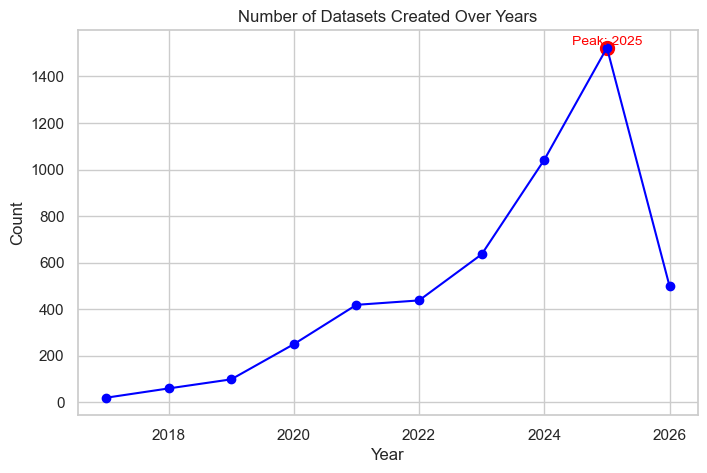

In [12]:
year_count = df.groupby("Year").size()

plt.figure(figsize=(8,5))
plt.plot(year_count.index, year_count.values, marker="o", color="blue")

# 🔥 find peak
peak_year = year_count.idxmax()
peak_value = year_count.max()

# 🔥 highlight peak
plt.scatter(peak_year, peak_value, color="red", s=100)

# 🔥 annotate
plt.text(peak_year, peak_value,
         f"Peak: {peak_year}",
         ha='center', va='bottom', fontsize=10, color='red')

plt.title("Number of Datasets Created Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)

plt.show()

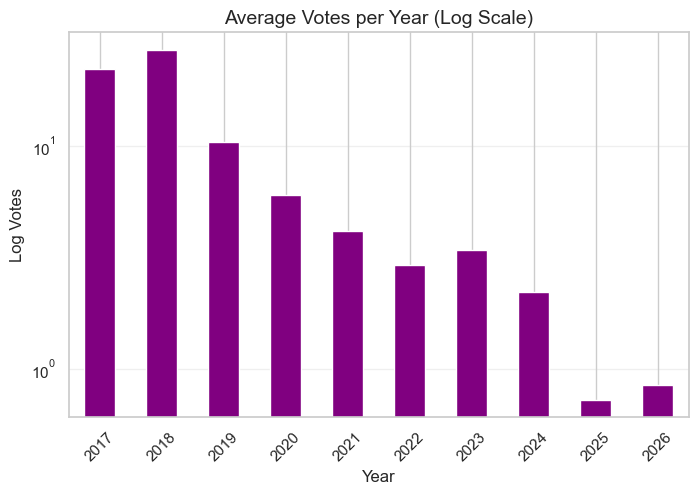

In [13]:
year_data["TotalVotes"].plot(kind="bar", color="purple")

plt.yscale("log")

plt.title("Average Votes per Year (Log Scale)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Log Votes")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

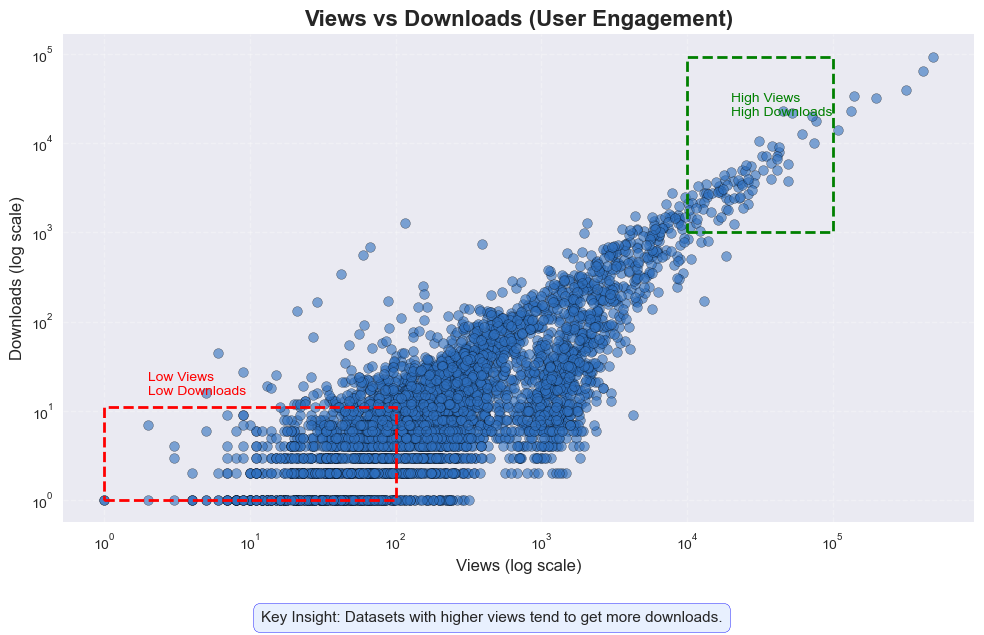

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.figure(figsize=(10,6))

# scatter plot
plt.scatter(
    df["TotalViews"],
    df["TotalDownloads"],
    color="#2E6FBE",
    alpha=0.6,
    edgecolors="black",
    linewidths=0.3
)

# log scale
plt.xscale("log")
plt.yscale("log")

# title & labels
plt.title("Views vs Downloads (User Engagement)", fontsize=16, fontweight="bold")
plt.xlabel("Views (log scale)", fontsize=12)
plt.ylabel("Downloads (log scale)", fontsize=12)

# grid
plt.grid(True, linestyle="--", alpha=0.3)

# 🔴 LOW REGION BOX
low_box = patches.Rectangle(
    (1, 1),      # start
    100, 10,     # width, height
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    linestyle='--'
)
plt.gca().add_patch(low_box)

plt.text(2, 15, "Low Views\nLow Downloads",
         color="red", fontsize=10)

# 🟢 HIGH REGION BOX
high_box = patches.Rectangle(
    (10000, 1000),
    90000, 90000,
    linewidth=2,
    edgecolor='green',
    facecolor='none',
    linestyle='--'
)
plt.gca().add_patch(high_box)

plt.text(20000, 20000, "High Views\nHigh Downloads",
         color="green", fontsize=10)

# 🔥 KEY INSIGHT BOX (BOTTOM)
plt.figtext(
    0.5, -0.05,
    "Key Insight: Datasets with higher views tend to get more downloads.",
    ha="center",
    fontsize=11,
    bbox=dict(facecolor="#E8F0FE", edgecolor="blue", boxstyle="round,pad=0.5")
)

plt.tight_layout()
plt.show()

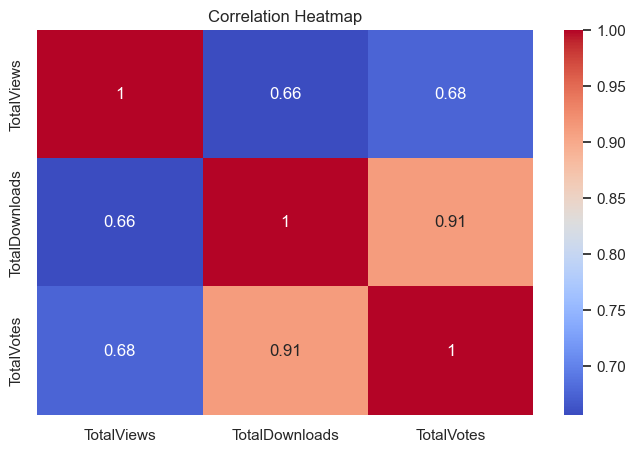

In [15]:
corr = df[["TotalViews","TotalDownloads","TotalVotes"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [15]:
df["DownloadCategory"] = pd.cut(df["TotalDownloads"],
                               bins=[0,50,500,5000],
                               labels=["Low","Medium","High"])

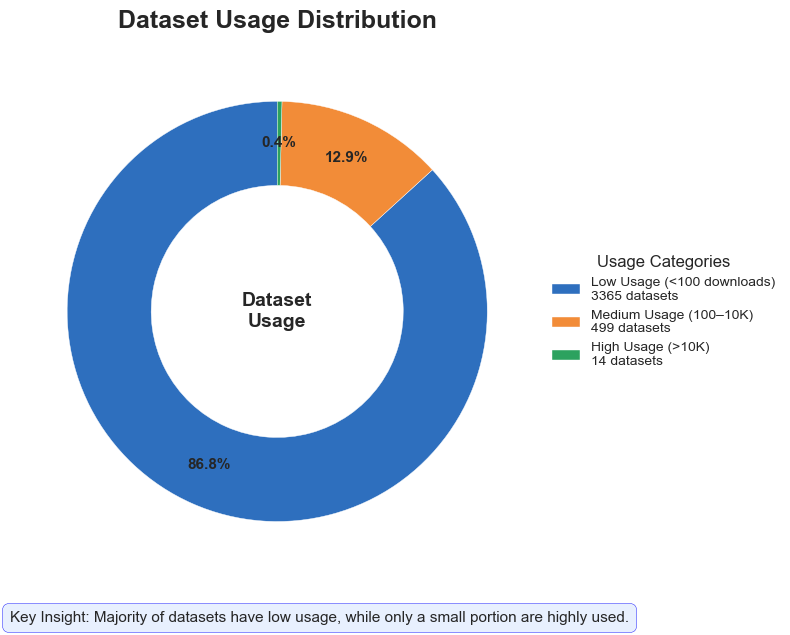

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# -------- CREATE USAGE CATEGORY --------
df["Usage"] = pd.cut(
    df["TotalDownloads"],
    bins=[0, 100, 10000, df["TotalDownloads"].max()],
    labels=["Low Usage", "Medium Usage", "High Usage"]
)

usage_counts = df["Usage"].value_counts().sort_index()

labels = usage_counts.index
sizes = usage_counts.values

colors = ["#2E6FBE", "#F28C38", "#2CA25F"]

# -------- PLOT --------
plt.figure(figsize=(10,6))

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white"),
    pctdistance=0.8,
    textprops={'fontsize':11, 'weight':'bold'}
)

# -------- CENTER TEXT --------
plt.text(0, 0, "Dataset\nUsage", ha="center", va="center",
         fontsize=14, fontweight="bold")

# -------- TITLE --------
plt.title(
    "Dataset Usage Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# -------- LEGEND (SIDE BOX STYLE) --------
legend_labels = [
    f"Low Usage (<100 downloads)\n{sizes[0]} datasets",
    f"Medium Usage (100–10K)\n{sizes[1]} datasets",
    f"High Usage (>10K)\n{sizes[2]} datasets"
]

plt.legend(
    wedges,
    legend_labels,
    title="Usage Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=12
)

# -------- KEY INSIGHT BOX --------
plt.figtext(
    0.5, -0.05,
    "Key Insight: Majority of datasets have low usage, while only a small portion are highly used.",
    ha="center",
    fontsize=11,
    bbox=dict(facecolor="#E8F0FE", edgecolor="blue", boxstyle="round,pad=0.5")
)

plt.tight_layout()
plt.show()

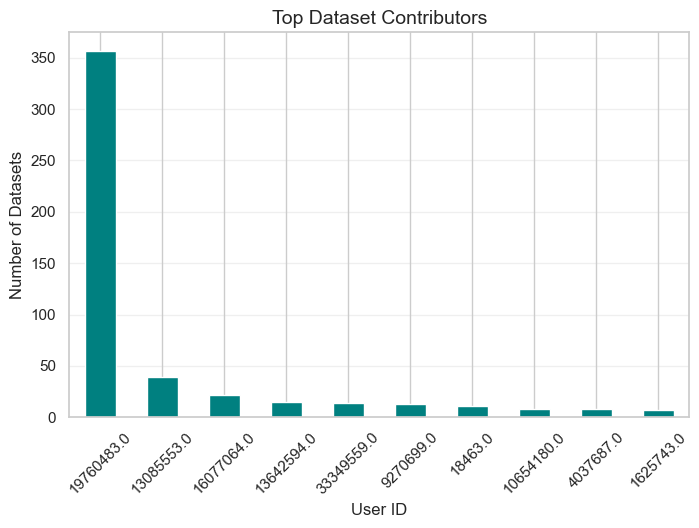

In [21]:
df["OwnerUserId"].value_counts().head(10).plot(
    kind="bar",
    color="teal"
)

plt.title("Top Dataset Contributors", fontsize=14)
plt.xlabel("User ID")
plt.ylabel("Number of Datasets")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

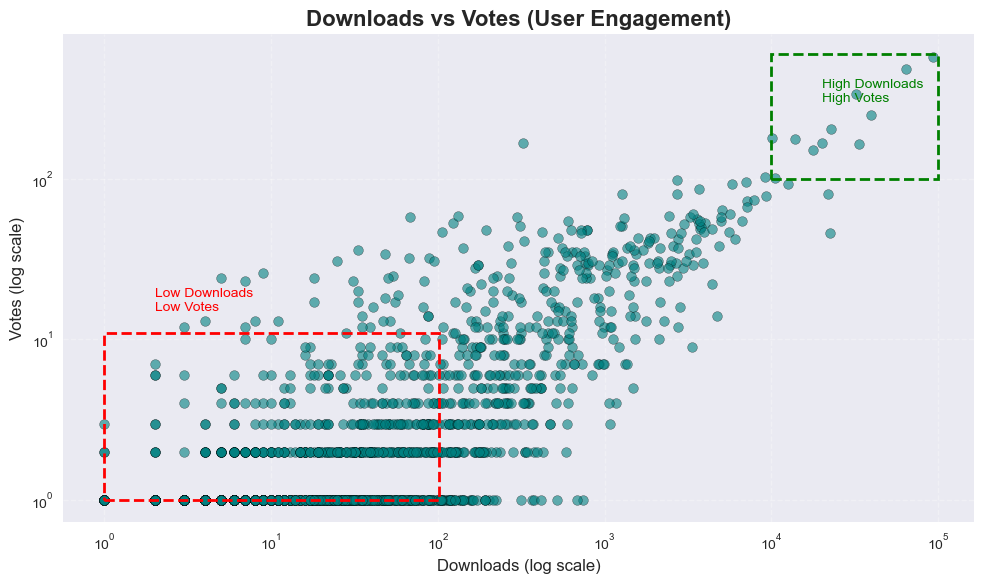

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.figure(figsize=(10,6))

# scatter plot
plt.scatter(
    df["TotalDownloads"],
    df["TotalVotes"],
    color="teal",
    alpha=0.6,
    edgecolors="black",
    linewidths=0.3
)

# log scale
plt.xscale("log")
plt.yscale("log")

# titles
plt.title("Downloads vs Votes (User Engagement)", fontsize=16, fontweight="bold")
plt.xlabel("Downloads (log scale)", fontsize=12)
plt.ylabel("Votes (log scale)", fontsize=12)

# grid
plt.grid(True, linestyle="--", alpha=0.3)

# 🔥 LOW REGION BOX (important fix)
low_box = patches.Rectangle(
    (1, 1),      # starting point
    100, 10,     # width, height
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    linestyle='--'
)
plt.gca().add_patch(low_box)

plt.text(2, 15, "Low Downloads\nLow Votes", color="red", fontsize=10)

# 🔥 HIGH REGION BOX
high_box = patches.Rectangle(
    (10000, 100),
    90000, 500,
    linewidth=2,
    edgecolor='green',
    facecolor='none',
    linestyle='--'
)
plt.gca().add_patch(high_box)

plt.text(20000, 300, "High Downloads\nHigh Votes", color="green", fontsize=10)

plt.tight_layout()
plt.show()

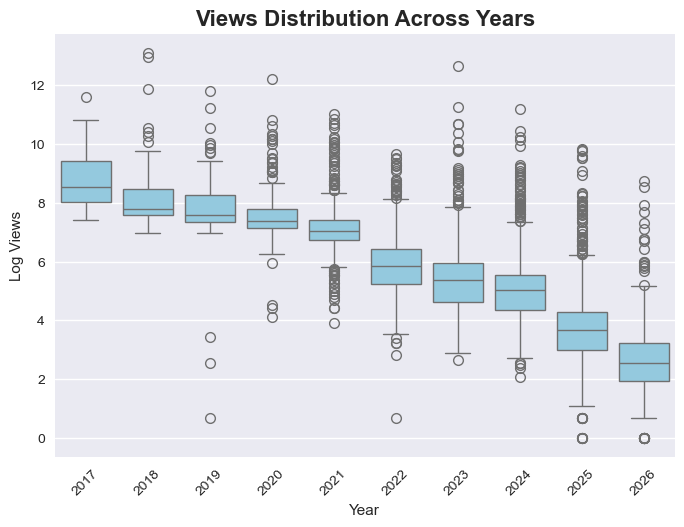

In [36]:
sns.boxplot(
    x="Year",
    y=np.log1p(df["TotalViews"]),
    data=df,
    color="skyblue"
)

plt.title("Views Distribution Across Years", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Log Views")

plt.xticks(rotation=45)

plt.show()